InsightReach es una empresa de marketing digital especializada en campañas personalizadas para negocios locales. Con el crecimiento de su base de clientes y la expansión a nuevos mercados, la empresa busca optimizar su estrategia de segmentación para mejorar la efectividad de sus campañas.

Como postulante, tu desafío es demostrar tu capacidad para analizar, enriquecer e interpretar bases de datos complejas para generar recomendaciones accionables. Tu rol simula el trabajo de un profesional en un entorno real, donde deberás construir análisis sólidos, justificar decisiones y comunicar resultados de manera clara y estructurada

Objetivos del PI:

- Explorar y comprender estructuras de datos relevantes provenientes de fuentes diversas.
- Aplicar técnicas de limpieza y transformación de datos para preparar datasets para análisis.
- Utilizar librerias de Python como pandas, numpy, matplotlib y seaborn para realizar análisis exploratorios de los datos (EDA)
- Conectar con una API externa (Yelp) para enriquecer un dataset con información contextual e implementar técnicas de web scraping para extraer datos relevantes de páginas web.
- Interpretar los resultados del análisis para generar recomendaciones accionables.
- Documentar el proceso de análisis de forma clara, estructurada y reproducible.

Detalle Avance 1:
1. Cargar y explorar una base de datos de clientes
2. Filtrar la base de datos para un país especifico
3. Realizar la limpieza de los datos, identificar valores nulos, duplicados y errores.
4. Generar tablar básicas para entender la distribución de variables como género, duración de sesión, calificaciones, etc.
5. Comenzar a documentar en el notebook Avance_1_EDA.pynb

Punto 1: Cargar y explorar una base de datos de clientes

In [2]:
#Comenzamos importando las librerias necesarias para el análisis:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"C:/Users/Enzo/OneDrive/Escritorio/Data Science Henry/P1/base_datos_restaurantes_USA_v2.csv")
df

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4862097674,Robert,Cortez,20.0,Masculino,Houston,Alto,-3,30.82,Sí,Sí,Vegano,Sí,NaN,garciagregory@example.net,Tarjeta,5781
29996,9458262482,Michael,Holt,78.0,Masculino,Denver,Alto,5,45.04,No,No,Mariscos,No,NaN,jimmy77@example.org,Efectivo,7652
29997,3412365931,Rebecca,Henry,77.0,Femenino,San Diego,Muy Alto,7,93.55,No,Sí,Mariscos,Sí,NaN,NaN,Efectivo,12639
29998,8853079811,Tamara,Griffin,77.0,Femenino,Chicago,Bajo,1,6.18,Sí,No,Otro,No,(243)658-6543x11668,NaN,Tarjeta,1057


Paso 2: Filtrar la base de datos para una ciudad especifica e iniciamos un analisis exploratorio de la misma

In [4]:
##Identificamos las ciudades existentes en el dataframe

df['ciudad_residencia'].unique()

array(['Miami', 'Denver', 'Boston', 'San Diego', 'Dallas', 'NYC',
       'Seattle', 'Chicago', 'Houston', 'Phoenix'], dtype=object)

In [5]:
df_boston = df[df['ciudad_residencia'] == 'Boston']

Paso 3: Realizar la limpieza de los datos, identificar valores nulos, duplicados y errores.

In [6]:
#Observamos las primeras 5 filas del dataset filtrado: 
df_boston.head()

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
7,8373803828,Julie,Russo,66.0,Femenino,Boston,Muy Alto,9,19.94,No,Sí,Vegetariano,Sí,NaN,NaN,Efectivo,13456
9,5394273061,Sara,Ball,37.0,Femenino,Boston,Bajo,1,11.35,Sí,No,Carnes,No,563-346-4749x6591,smithstacy@example.com,Efectivo,1197
19,9336353877,Mary,Bentley,29.0,Femenino,Boston,Medio,2,11.22,No,Sí,Vegetariano,No,6382528579,NaN,Efectivo,2052
26,1232293617,Elizabeth,Griffin,51.0,Femenino,Boston,Alto,6,51.46,No,No,Vegetariano,Sí,906.282.9481,NaN,Efectivo,8499


In [7]:
#Tambien observamos la cantidad de filas y columnas existentes en nuestro dataframe filtrado
print(df_boston.shape)

(2547, 17)


In [8]:
#Identificamos el tipo de dato que contienen las respectivas columnas
df_boston[[
    "edad", 
    "promedio_gasto_comida", 
    "preferencias_alimenticias", 
    "telefono_contacto", 
    "correo_electronico"
]].dtypes

edad                         float64
promedio_gasto_comida        float64
preferencias_alimenticias     object
telefono_contacto             object
correo_electronico            object
dtype: object

In [9]:
#Juntamos nombre y apellido en una sola columna y las descartamos:
df_boston["cliente"] = df_boston["nombre"] + " " + df_boston["apellido"]
df_boston = df_boston.drop(columns=["nombre", "apellido"])


#Reordenamos las columnas para que cliente quede en la segunda posición
cols = df_boston.columns.tolist()
cols.insert(1, cols.pop(cols.index("cliente")))
df_boston = df_boston[cols]

C:\Users\Enzo\AppData\Local\Temp\ipykernel_19604\1264635997.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_boston["cliente"] = df_boston["nombre"] + " " + df_boston["apellido"]


In [10]:
#Verificamos valores duplicados en las columnas que creemos podría haber problemas y en el caso que haya diplicados se eliminen dejando solo la primera

columnas = ['id_persona']
df_boston = df_boston.drop_duplicates(subset=columnas, keep='first')

In [11]:
#El siguiente paso es identificar la cantidad de nulos por columna

nulos_boston = df_boston.isnull().sum()
print(nulos_boston)

# Tenemos nulos en las columnas: edad, promedio_gasto_comida, preferencias_alimenticias, telefono_contacto y correo_electronico

id_persona                      0
cliente                         0
edad                           10
genero                          0
ciudad_residencia               0
estrato_socioeconomico          0
frecuencia_visita               0
promedio_gasto_comida           6
ocio                            0
consume_licor                   0
preferencias_alimenticias     102
membresia_premium               0
telefono_contacto            1264
correo_electronico           1276
tipo_de_pago_mas_usado          0
ingresos_mensuales              0
dtype: int64


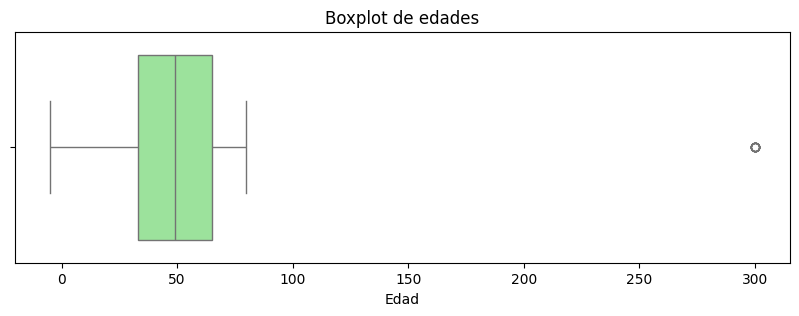

In [12]:
#A continuación realizamos un proceso de validación de la calidad de la información de los datos, 
# de las columna que mas nos interesan para rellenar los nulos obtenidos anteriormente en base a patrones de consumo (relaciones entre variables)

 #Edades: Establecemos un rango de edad menor a 0 y mayor a 100
df_boston[(df_boston['edad'] < 0) | (df_boston['edad'] > 100)].shape[0]
df_boston[(df_boston['edad'] < 0) | (df_boston['edad'] > 100)]['edad'].value_counts()

#Vemos que hay que tener en cuenta que existen valores de edad de 300 y -5, esto hay que considerarlo a la hora de 
# rellenar la variable edad o usarla para algun analisis particular

import matplotlib.pyplot as plt
import seaborn as sns



# Boxplot para detectar outliers
plt.figure(figsize=(10,3))
sns.boxplot(x=df_boston['edad'], color="lightgreen")
plt.title("Boxplot de edades")
plt.xlabel("Edad")
plt.show()

In [13]:
#Verificamos el género
df_boston['genero'].unique()
#No hay promblemas con el genero

array(['Masculino', 'Femenino'], dtype=object)

In [14]:
#Frecuencia de visita: Debería ser un número no negativo o distinto de 0:
df_boston[df_boston['frecuencia_visita'] <= 0]
#Aqui vemos inconsistencias en la frecuencia de visita (valores iguales a 0 y -3)

,id_persona,cliente,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
52,4899320322,John Anderson,50.0,Masculino,Boston,Bajo,0,0.00,Sí,No,NaN,No,001-238-768-6123x5879,mendozajamie@example.net,Tarjeta,1547
257,8641948398,Lisa Trujillo,58.0,Femenino,Boston,Bajo,0,0.00,Sí,No,Mariscos,No,NaN,emily17@example.org,Tarjeta,1199
298,1640979105,Ashley Rodriguez,22.0,Femenino,Boston,Bajo,0,0.00,Sí,Sí,Carnes,No,+1-448-904-4635x800,NaN,App,995
395,7893058289,Barbara Baker,45.0,Femenino,Boston,Bajo,0,0.00,No,Sí,Carnes,No,(314)616-3502,NaN,Tarjeta,1228
496,1420654268,Keith Hensley,42.0,Masculino,Boston,Muy Alto,-3,104.17,Sí,Sí,Vegano,Sí,NaN,raymondbeasley@example.org,Efectivo,9806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29354,8914054579,Ellen Foster,41.0,Femenino,Boston,Medio,-3,30.28,Sí,No,Carnes,Sí,NaN,NaN,Efectivo,2071
29374,3461913325,Christopher Clark,56.0,Masculino,Boston,Bajo,0,0.00,No,Sí,Mariscos,No,621.285.1507,frankhayden@example.com,Tarjeta,1453
29665,1031654390,Eric Cortez,20.0,Masculino,Boston,Bajo,0,0.00,No,Sí,Carnes,No,NaN,NaN,Efectivo,1379
29750,6869865000,Sandra Cisneros,37.0,Femenino,Boston,Alto,-3,20.93,Sí,No,Carnes,No,NaN,NaN,Tarjeta,6999


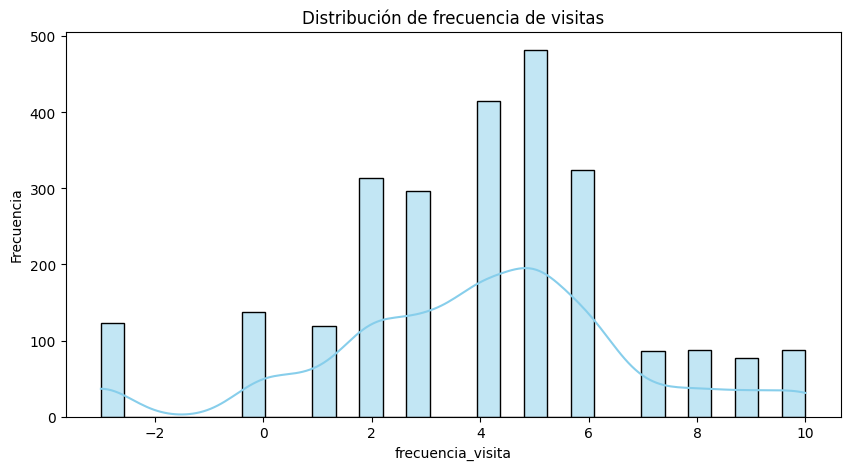

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df_boston['frecuencia_visita'], bins=30, kde=True, color="skyblue")
plt.title("Distribución de frecuencia de visitas")
plt.xlabel("frecuencia_visita")
plt.ylabel("Frecuencia")
plt.show()

In [16]:
#En cuanto al promedio de gasto en comida:
df_boston[df_boston['promedio_gasto_comida'] <= 0].shape[0]
#Existen 138 valores menores o iguales a cero imputados a promedio gasto de comida, esto es inconsistente con lo que uno quiere reflejar

138

In [17]:
#Con las variables categoricas "ocio" y "consume_licor" no parece haber problemas
df_boston[~df_boston['ocio'].isin(['Sí', 'No'])].shape[0]

0

In [18]:
df_boston[~df_boston['consume_licor'].isin(['Sí', 'No'])].shape[0]

0

In [19]:
#Ingresos mensuales deberían ser >= 0 y en un rango lógico.
df_boston[df_boston['ingresos_mensuales'] <= 0].shape[0]
#Tampoco hay inconsistencias con esta variable

0

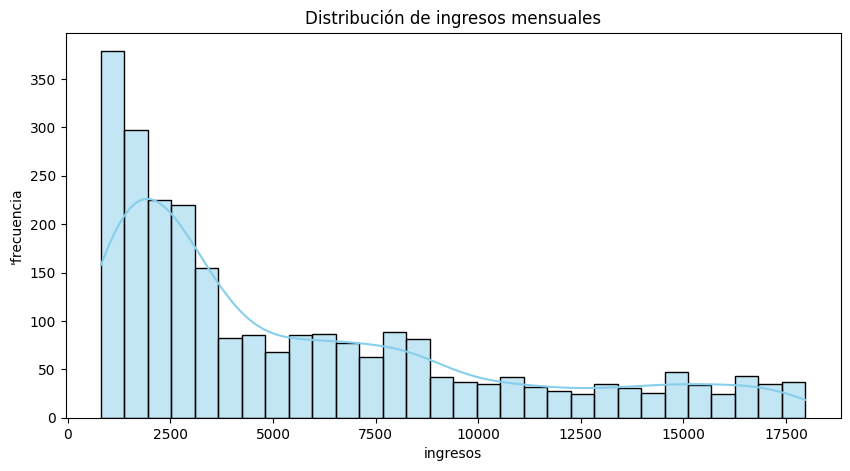

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(df_boston['ingresos_mensuales'], bins=30, kde=True, color="skyblue")
plt.title("Distribución de ingresos mensuales")
plt.xlabel("ingresos")
plt.ylabel("'frecuencia")
plt.show()

Se detectaron inconsistencias (datos nulos o fuera de rango) en las columnas: 
1. EDAD
2. FRECUENCIA DE VISITA
3. PROMEDIO GASTO EN COMIDA
4. PREFERENCIAS ALIMENTICIAS
5. TELEFONO DE CONTACTO
6. CORREO ELECTRONICO. 

El siguiente paso es normalizar (dentro de lo posible), la información erronea dentro de cada una de estas columnas.

In [21]:
#Comenzamos por las columnas numericas, describiendo sus caracteristicas:
columnas_numericas = ['edad', 'frecuencia_visita', 'promedio_gasto_comida']
df[columnas_numericas].describe()

,edad,frecuencia_visita,promedio_gasto_comida
count,29899.000000,30000.000000,29855.000000
mean,49.665006,3.896133,32.603452
std,23.839550,2.741532,26.402601
min,-5.000000,-3.000000,0.000000
25%,33.000000,2.000000,13.290000
50%,49.000000,4.000000,25.510000
75%,65.000000,5.000000,44.400000
max,300.000000,10.000000,149.970000


In [22]:
#Para el caso de los errores en la columna edad y los nulos, podríamos elegir el promedio: 49.51 o la mediana 49, pero al hacer esto, si luego dividimos los clientes
#por estratos de edades podriamos estar sesgando la muestra asignandole una gran proporción a los estratos medios, con lo cual se optó por buscar relaciones
#entre otras variables para asginar una edad correspondiende

# Definimos los valores inválidos:
invalidos = [-5, 300]

# Reemplazar valores inválidos por NaN para tratarlos igual que los nulos
df_boston['edad'] = df_boston['edad'].replace(invalidos, np.nan)

# Calcular la mediana de edad por grupo (estrato + gasto + genero)
medianas = df_boston.groupby(['estrato_socioeconomico', 'promedio_gasto_comida', 'genero'])['edad'].median()

# Función que asigna la mediana del grupo
def imputar_edad(row):
    if pd.isna(row['edad']):
        return medianas.loc[(row['estrato_socioeconomico'], row['promedio_gasto_comida'], row['genero'])]
    else:
        return row['edad']

# Aplicar la función
df_boston['edad'] = df_boston.apply(imputar_edad, axis=1)

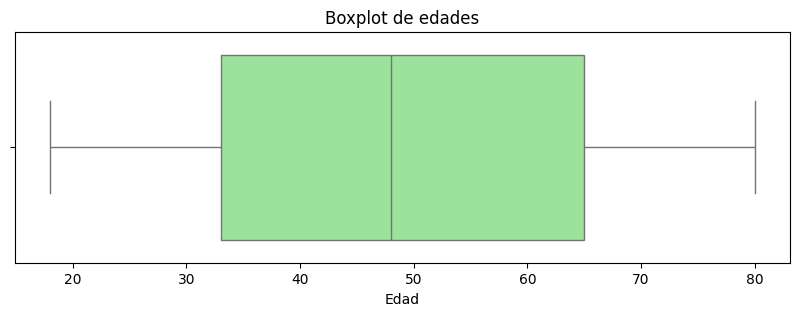

In [23]:
#Boxplots con edades corregidas
plt.figure(figsize=(10,3))
sns.boxplot(x=df_boston['edad'], color="lightgreen")
plt.title("Boxplot de edades")
plt.xlabel("Edad")
plt.show()

In [24]:
#En el caso de la frecuencia de visita:
df_boston['frecuencia_visita'].value_counts()

frecuencia_visita
 5     482
 4     415
 6     324
 2     313
 3     296
 0     138
-3     123
 1     119
 8      87
 10     87
 7      86
 9      77
Name: count, dtype: int64

In [25]:
#Analizamos primero la frecuencia en 0:
df_cero_visitas = df_boston[df_boston['frecuencia_visita'] == 0]
df_cero_visitas.describe(include='all')

#Para este caso, hay que tener en cuenta en primer lugar, el origen de los datos, si surge de una base de clientes o de una encuesta realizada en otros medios, 
# porque la información adicional de cada columna podría utilizarse

,id_persona,cliente,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
count,1.380000e+02,138,138.000000,138,138,138,138.0,138.0,138,138,130,138,74,71,138,138.000000
unique,NaN,138,NaN,2,1,1,NaN,NaN,2,2,6,1,74,71,4,NaN
top,NaN,John Anderson,NaN,Femenino,Boston,Bajo,NaN,NaN,No,Sí,Vegetariano,No,001-238-768-6123x5879,mendozajamie@example.net,Efectivo,NaN
freq,NaN,1,NaN,73,138,138,NaN,NaN,77,80,40,138,1,1,50,NaN
mean,5.512694e+09,NaN,49.268116,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1234.847826
std,2.507982e+09,NaN,16.985412,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.913464
min,1.031654e+09,NaN,18.000000,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,820.000000
25%,3.520199e+09,NaN,36.000000,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1044.750000
50%,5.820495e+09,NaN,48.000000,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1229.000000
75%,7.649798e+09,NaN,61.000000,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1443.500000


In [26]:
#Sin embargo, para este trabajo se decidió eliminar aquellas filas que contengan esta particularidad
df_boston = df_boston[df_boston['frecuencia_visita'] != 0]

In [27]:
#En el caso de la frecuencia en -3 vemos que existen otras variables de utilidad, con lo cual podríamos rellenar esta información con otras variables relacionadas
df_menostres_visitas = df_boston[df_boston['frecuencia_visita'] == -3]
df_menostres_visitas.describe(include='all')

,id_persona,cliente,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
count,1.230000e+02,123,122.000000,123,123,123,123.0,123.000000,123,123,116,123,62,60,123,123.000000
unique,NaN,123,NaN,2,1,4,NaN,NaN,2,2,6,2,62,60,4,NaN
top,NaN,Keith Hensley,NaN,Femenino,Boston,Medio,NaN,NaN,Sí,Sí,Vegetariano,Sí,445.962.1555,raymondbeasley@example.org,Efectivo,NaN
freq,NaN,1,NaN,63,123,36,NaN,NaN,72,73,32,69,1,1,56,NaN
mean,5.472033e+09,NaN,49.172131,NaN,NaN,NaN,-3.0,32.879837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6270.008130
std,2.718046e+09,NaN,19.089910,NaN,NaN,NaN,0.0,24.739704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4834.167247
min,1.012310e+09,NaN,18.000000,NaN,NaN,NaN,-3.0,5.620000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,813.000000
25%,3.090822e+09,NaN,36.000000,NaN,NaN,NaN,-3.0,13.525000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2452.500000
50%,5.367513e+09,NaN,46.500000,NaN,NaN,NaN,-3.0,26.480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5137.000000
75%,7.624876e+09,NaN,66.750000,NaN,NaN,NaN,-3.0,47.705000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9286.000000


In [28]:
#Existen dos alternativas:
#1 Considerar esta variable como un error de imputación y reemplazarla por 3, esto daria una distribución de frecuencias mas normalizada
#2 Reemplazar el -3 por una frecuencia acorde, a partir de la relaciones entre el resto de las variables, esto daria una distribución mas realista
#Para este trabajo se optó por la opcion 2 tomando como variables de analisis la edad, el promedio_gasto_comida y el estrato_socioeconomico

#Creamos una mascara para diferenciar aquellos valores que queremos reemplazar
mask = df_boston['frecuencia_visita'] == -3
df_valido = df_boston[~mask]

# Calcular mediana de frecuencia por estrato + gasto + edad del df_valido
medianas = df_valido.groupby(['estrato_socioeconomico', 'promedio_gasto_comida', 'edad'])['frecuencia_visita'].median()

# Función para asignar frecuencia acorde
def asignar_frecuencia(row):
    if row['frecuencia_visita'] != -3:
        return row['frecuencia_visita']
    key = (row['estrato_socioeconomico'], row['promedio_gasto_comida'], row['edad'])
    if key in medianas:
        return int(medianas[key])
    else:
        submediana = df_valido[
            (df_valido['estrato_socioeconomico'] == row['estrato_socioeconomico']) &
            (df_valido['promedio_gasto_comida'] == row['promedio_gasto_comida'])
        ]['frecuencia_visita'].median()
        if not pd.isna(submediana):
            return int(submediana)
        else:
            # último fallback: mediana del estrato
            return int(df_valido[df_valido['estrato_socioeconomico'] == row['estrato_socioeconomico']]['frecuencia_visita'].median())

# Aplicamos la mediana para corregir los -3
df_boston['frecuencia_visita'] = df_boston.apply(asignar_frecuencia, axis=1)

# Revisar distribución final
print(df_boston['frecuencia_visita'].value_counts().sort_index())

frecuencia_visita
1     121
2     331
3     325
4     421
5     516
6     325
7      86
8     118
9      78
10     88
Name: count, dtype: int64


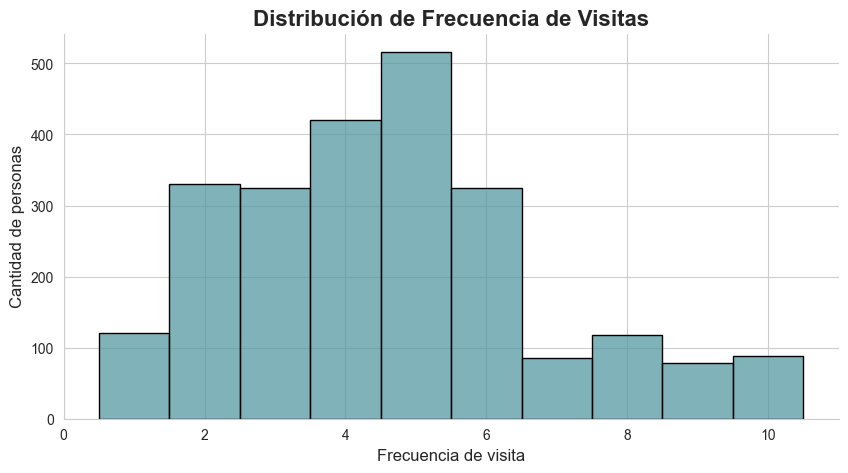

In [29]:
plt.figure(figsize=(10,5))
sns.set_style("whitegrid")

# histograma tipo barras pegadas
sns.histplot(
    data=df_boston,
    x="frecuencia_visita",
    discrete=True,     # fuerza barras pegadas en datos enteros
    color="#5499A2",
    edgecolor="black"
)

plt.title("Distribución de Frecuencia de Visitas", fontsize=16, weight="bold")
plt.xlabel("Frecuencia de visita", fontsize=12)
plt.ylabel("Cantidad de personas", fontsize=12)

# quitar bordes superiores y derechos
sns.despine()

plt.show()

In [30]:
#Continuamos con el analisis descriptivo de las variables categoricas con nulos
df_boston[['preferencias_alimenticias', 'telefono_contacto', 'correo_electronico']].describe()

,preferencias_alimenticias,telefono_contacto,correo_electronico
count,2315,1209,1200
unique,6,1209,1198
top,Vegetariano,+1-770-899-2418x07194,crobinson@example.com
freq,668,1,2


In [31]:
#En cuanto a los nulos de la columna preferencias_alimenticias
df_boston['preferencias_alimenticias'].value_counts(dropna=False)

preferencias_alimenticias
Vegetariano    668
Carnes         505
Mariscos       465
Pescado        254
Vegano         229
Otro           194
NaN             94
Name: count, dtype: int64

In [32]:
#Existen varias alternativas para su tratamiento:
# 1. completar los nulos con el dato que mas se repite. En este caso es "Vegetariano", 
# sin embargo corremos el riesgo de cesgar el analisis ya que no estamos en la capacidad de afirmar que si quiera la mayoria de los nulos son Vegetarianos
# 2. Buscar relaciones entre las restantes variables y asignarle un valor.

mask_pref = df_boston['preferencias_alimenticias'].isna()
df_valido_pref = df_boston[~mask_pref]

# Calcular la moda de preferencias por estrato + gasto + edad
modas = df_valido_pref.groupby(['estrato_socioeconomico', 'promedio_gasto_comida', 'edad'])['preferencias_alimenticias'] \
            .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

# Función para asignar preferencia acorde
def asignar_preferencia(row):
    if pd.notna(row['preferencias_alimenticias']):
        return row['preferencias_alimenticias']
    key = (row['estrato_socioeconomico'], row['promedio_gasto_comida'], row['edad'])
    if key in modas and modas[key] is not None:
        return modas[key]
    else:
        submoda = df_valido_pref[
            (df_valido_pref['estrato_socioeconomico'] == row['estrato_socioeconomico']) &
            (df_valido_pref['promedio_gasto_comida'] == row['promedio_gasto_comida'])
        ]['preferencias_alimenticias'].mode()
        if not submoda.empty:
            return submoda.iloc[0]
        else:
            submoda2 = df_valido_pref[df_valido_pref['estrato_socioeconomico'] == row['estrato_socioeconomico']]['preferencias_alimenticias'].mode()
            if not submoda2.empty:
                return submoda2.iloc[0]
            else:
                return 'Desconocido'

# Aplicamos la función para reemplazar nulos y vemos la distribución final
df_boston['preferencias_alimenticias'] = df_boston.apply(asignar_preferencia, axis=1)

df_boston['preferencias_alimenticias'].value_counts()

preferencias_alimenticias
Vegetariano    754
Carnes         507
Mariscos       467
Pescado        254
Vegano         232
Otro           195
Name: count, dtype: int64

In [33]:
#Guardamos nuestro dataframe en un csv
df_boston.to_csv("df_clientes_boston.csv", index=False, encoding="utf-8")

Paso 4. Generar tablas básicas para entender la distribución de variables como género, duración de sesión, calificaciones, etc.

In [34]:
#Empezamos por generar estratos de edades para detectar patrones de consumo

bins = [18, 30, 45, 60, 100]  # rangos
labels = ['18-30', '31-45', '46-60', '60+']

df_boston['estrato_edad'] = pd.cut(df_boston['edad'], bins=bins, labels=labels, right=False)

In [35]:
#Vinculamos los estratos generados con las preferencias alimnenticias
tabla_pref = df_boston.groupby(['estrato_edad', 'preferencias_alimenticias']).size().unstack(fill_value=0)
tabla_pref


C:\Users\Enzo\AppData\Local\Temp\ipykernel_19604\3480544882.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_pref = df_boston.groupby(['estrato_edad', 'preferencias_alimenticias']).size().unstack(fill_value=0)


preferencias_alimenticias,Carnes,Mariscos,Otro,Pescado,Vegano,Vegetariano
estrato_edad,,,,,,
18-30,94,86,33,51,48,152
31-45,134,117,46,54,59,174
46-60,117,85,44,69,50,180
60+,156,176,68,76,74,243


In [36]:
#Se observa que los estratos de entre 18 y 60 años son mas propensos a consumir el menu vegetariano y las carnes, 
# mientras que el mayor a 60 prefiere vegetariano y mariscos y en una menor proporcion las carnes
tabla_porc = tabla_pref.div(tabla_pref.sum(axis=1), axis=0)
tabla_porc

preferencias_alimenticias,Carnes,Mariscos,Otro,Pescado,Vegano,Vegetariano
estrato_edad,,,,,,
18-30,0.202586,0.185345,0.071121,0.109914,0.103448,0.327586
31-45,0.229452,0.200342,0.078767,0.092466,0.101027,0.297945
46-60,0.214679,0.155963,0.080734,0.126606,0.091743,0.330275
60+,0.196721,0.221942,0.085750,0.095839,0.093317,0.306431


In [37]:
#Tambien generamos una tabla para observar la distribución de generos por estrato de edad:
tabla_genero = df_boston.groupby(['estrato_edad', 'genero']).size().unstack(fill_value=0)

tabla_genero["Total"] = tabla_genero.sum(axis=1)
tabla_genero
# Se observa que existe un mayor numero de personas +60 en relación a los restantes estratos de edad

C:\Users\Enzo\AppData\Local\Temp\ipykernel_19604\1403400187.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_genero = df_boston.groupby(['estrato_edad', 'genero']).size().unstack(fill_value=0)


genero,Femenino,Masculino,Total
estrato_edad,,,
18-30,245,219,464
31-45,323,261,584
46-60,269,276,545
60+,389,404,793


In [38]:
#Armamos una función del top 3 de preferencias alimenticias dependiendo del genero y el estrato de edad. Se destaca que para todos la moda es el menu vegetariano,
#mientras que para el segundo y tercer lugar puede variar entre carnes y mariscos.

def top3_frecuencias(x):
    conteo = x.value_counts()  # ordena de mayor a menor frecuencia automáticamente
    top3 = conteo.index[:3]    # toma hasta los 3 primeros valores
    # rellenar con None si hay menos de 3 valores
    return pd.Series([top3[i] if i < len(top3) else None for i in range(3)], 
                     index=['primero', 'segundo', 'tercero'])

moda_ordenada = df_boston.groupby(['estrato_edad', 'genero'])['preferencias_alimenticias'].apply(top3_frecuencias).reset_index()

moda_ordenada

C:\Users\Enzo\AppData\Local\Temp\ipykernel_19604\2541679873.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  moda_ordenada = df_boston.groupby(['estrato_edad', 'genero'])['preferencias_alimenticias'].apply(top3_frecuencias).reset_index()


,estrato_edad,genero,level_2,preferencias_alimenticias
0,18-30,Femenino,primero,Vegetariano
1,18-30,Femenino,segundo,Carnes
2,18-30,Femenino,tercero,Mariscos
3,18-30,Masculino,primero,Vegetariano
4,18-30,Masculino,segundo,Mariscos
5,18-30,Masculino,tercero,Carnes
6,31-45,Femenino,primero,Vegetariano
7,31-45,Femenino,segundo,Carnes
8,31-45,Femenino,tercero,Mariscos
9,31-45,Masculino,primero,Vegetariano


In [39]:
#Finalmente dividimos las edades de concurrencia por nivel socioeconomico, donde la moda es el nivel socioeconomico "Alto", seguido por los niveles medio y muy alto
#Con lo cual el la marca es de un nivel alto

moda_estrato_top3 = df_boston.groupby('estrato_edad')['estrato_socioeconomico'].apply(top3_frecuencias).reset_index()
moda_estrato_top3

C:\Users\Enzo\AppData\Local\Temp\ipykernel_19604\2400919794.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  moda_estrato_top3 = df_boston.groupby('estrato_edad')['estrato_socioeconomico'].apply(top3_frecuencias).reset_index()


,estrato_edad,level_1,estrato_socioeconomico
0,18-30,primero,Alto
1,18-30,segundo,Medio
2,18-30,tercero,Muy Alto
3,31-45,primero,Alto
4,31-45,segundo,Medio
5,31-45,tercero,Muy Alto
6,46-60,primero,Alto
7,46-60,segundo,Medio
8,46-60,tercero,Muy Alto
9,60+,primero,Alto
